In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

In [7]:
daily = pd.read_csv('../data/processed/daily_revenue_with_intervention.csv', 
                    index_col=0, parse_dates=True)
daily = daily.asfreq('D')
print(daily.head())
print(f"\nPeriod: {daily.index.min()} to {daily.index.max()}")

             revenue  revenue_original
date                                  
2010-12-01  46376.49          46376.49
2010-12-02  47316.53          47316.53
2010-12-03  23921.71          23921.71
2010-12-04      0.00              0.00
2010-12-05  31771.60          31771.60

Period: 2010-12-01 00:00:00 to 2011-12-09 00:00:00


In [8]:
intervention_date = '2011-04-01'
pre = daily[daily.index < intervention_date].copy()
post = daily[daily.index >= intervention_date].copy()

print(f"Pre-intervention days: {len(pre)}")
print(f"Post-intervention days: {len(post)}")

Pre-intervention days: 121
Post-intervention days: 253


In [10]:
train_prophet = pre.reset_index()
# The index name is 'date' (from CSV) – rename first column to 'ds'
train_prophet = train_prophet.rename(columns={train_prophet.columns[0]: 'ds', 'revenue': 'y'})
train_prophet['ds'] = pd.to_datetime(train_prophet['ds']).dt.tz_localize(None)

model = Prophet(weekly_seasonality=True, yearly_seasonality=False)
model.fit(train_prophet)

print("Model trained successfully")

20:56:17 - cmdstanpy - INFO - Chain [1] start processing
20:56:17 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully


In [11]:
future = model.make_future_dataframe(periods=len(post), include_history=False)
forecast = model.predict(future)

counterfactual = forecast['yhat'].values
actual = post['revenue'].values
dates = post.index

print(f"Forecast days: {len(counterfactual)}")

Forecast days: 253


In [12]:
avg_actual = actual.mean()
avg_cf = counterfactual.mean()
absolute_effect = avg_actual - avg_cf
relative_effect = (absolute_effect / avg_cf) * 100

print("="*50)
print("Causal Impact Results")
print("="*50)
print(f"Average actual revenue after intervention: £{avg_actual:,.0f}")
print(f"Average counterfactual revenue (no intervention): £{avg_cf:,.0f}")
print(f"Absolute daily effect: £{absolute_effect:,.0f}")
print(f"Relative effect: {relative_effect:.1f}%")

Causal Impact Results
Average actual revenue after intervention: £31,905
Average counterfactual revenue (no intervention): £15,584
Absolute daily effect: £16,321
Relative effect: 104.7%


In [13]:
n_bootstrap = 1000
effects = []

for i in range(n_bootstrap):
    idx = np.random.choice(len(actual), len(actual), replace=True)
    sample_actual = actual[idx].mean()
    sample_cf = counterfactual[idx].mean()
    effects.append(sample_actual - sample_cf)

ci_lower = np.percentile(effects, 2.5)
ci_upper = np.percentile(effects, 97.5)
prob_positive = (np.array(effects) > 0).mean()

print(f"\n95% CI for daily absolute effect: £{ci_lower:,.0f} to £{ci_upper:,.0f}")
print(f"Probability of positive effect: {prob_positive:.3f}")


95% CI for daily absolute effect: £13,705 to £19,095
Probability of positive effect: 1.000


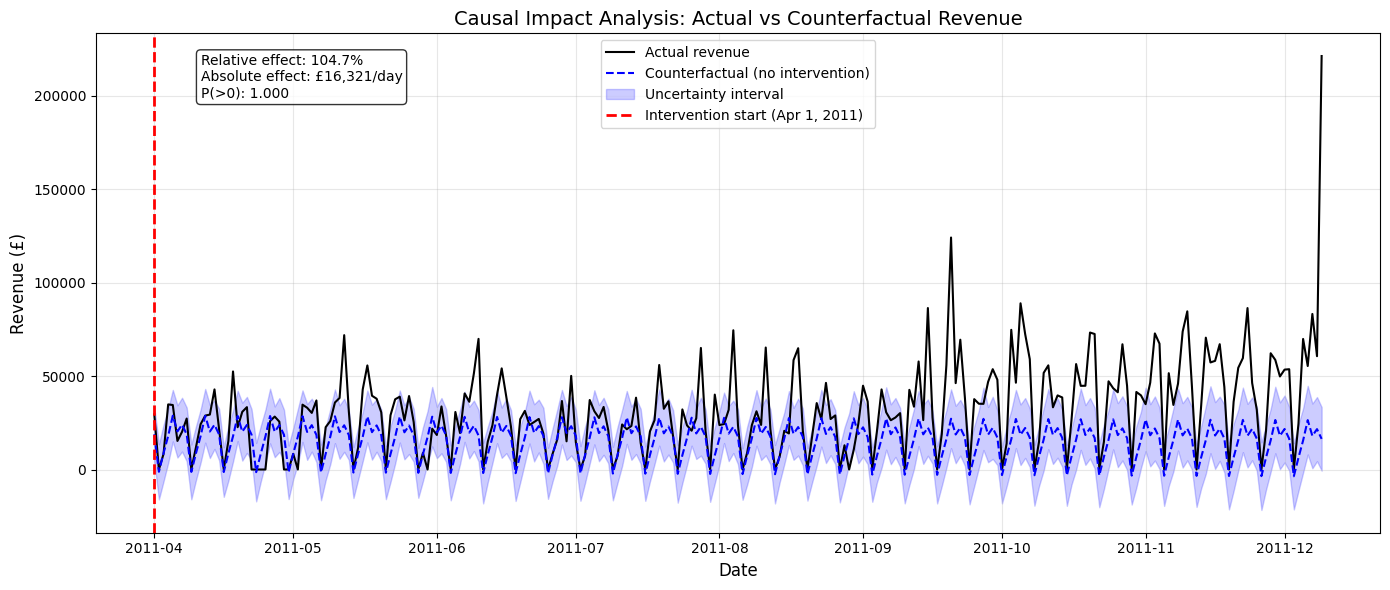

In [14]:
plt.figure(figsize=(14,6))
plt.plot(dates, actual, label='Actual revenue', color='black', linewidth=1.5)
plt.plot(dates, counterfactual, label='Counterfactual (no intervention)', color='blue', linestyle='--', linewidth=1.5)

std_error = forecast['yhat_upper'].values - forecast['yhat'].values
plt.fill_between(dates, 
                 counterfactual - std_error, 
                 counterfactual + std_error, 
                 alpha=0.2, color='blue', label='Uncertainty interval')

plt.axvline(pd.Timestamp(intervention_date), color='red', linestyle='--', linewidth=2, label='Intervention start (Apr 1, 2011)')
plt.title('Causal Impact Analysis: Actual vs Counterfactual Revenue', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue (£)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.text(dates[10], actual.max() * 0.9, 
         f'Relative effect: {relative_effect:.1f}%\nAbsolute effect: £{absolute_effect:,.0f}/day\nP(>0): {prob_positive:.3f}',
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

plt.tight_layout()
plt.savefig('../reports/causal_impact_manual.png', dpi=150)
plt.show()

In [15]:
results_df = pd.DataFrame({
    'date': dates,
    'actual': actual,
    'counterfactual': counterfactual,
    'effect': actual - counterfactual
})
results_df.to_csv('../data/processed/manual_causal_results.csv', index=False)
print("Results saved to '../data/processed/manual_causal_results.csv'")

Results saved to '../data/processed/manual_causal_results.csv'


In [16]:
# Diagnostic: Compare actual vs counterfactual means before and after
pre_actual_mean = pre['revenue'].mean()
post_actual_mean = actual.mean()
post_cf_mean = counterfactual.mean()

print(f"Pre-intervention actual mean: £{pre_actual_mean:,.0f}")
print(f"Post-intervention actual mean: £{post_actual_mean:,.0f}")
print(f"Post-intervention counterfactual mean: £{post_cf_mean:,.0f}")
print(f"Natural increase (pre to post actual): {(post_actual_mean/pre_actual_mean -1)*100:.1f}%")
print(f"Counterfactual vs pre: {(post_cf_mean/pre_actual_mean -1)*100:.1f}%")

Pre-intervention actual mean: £18,056
Post-intervention actual mean: £31,905
Post-intervention counterfactual mean: £15,584
Natural increase (pre to post actual): 76.7%
Counterfactual vs pre: -13.7%


In [17]:
# Placebo test: fake intervention date before real one
placebo_date = '2011-02-01'

pre_placebo = daily[daily.index < placebo_date].copy()
post_placebo = daily[(daily.index >= placebo_date) & (daily.index < intervention_date)].copy()

# Train Prophet on pre-placebo
train_placebo = pre_placebo.reset_index()
train_placebo = train_placebo.rename(columns={train_placebo.columns[0]: 'ds', 'revenue': 'y'})
train_placebo['ds'] = pd.to_datetime(train_placebo['ds']).dt.tz_localize(None)

model_placebo = Prophet(weekly_seasonality=True, yearly_seasonality=False)
model_placebo.fit(train_placebo)

# Forecast on post-placebo period
future_placebo = model_placebo.make_future_dataframe(periods=len(post_placebo), include_history=False)
forecast_placebo = model_placebo.predict(future_placebo)
cf_placebo = forecast_placebo['yhat'].values
actual_placebo = post_placebo['revenue'].values

# Effect
effect_placebo = actual_placebo.mean() - cf_placebo.mean()
print(f"Placebo test (fake intervention on {placebo_date}):")
print(f"Absolute effect: £{effect_placebo:,.0f}")
print(f"Relative effect: {(effect_placebo / cf_placebo.mean()) * 100:.1f}%")

21:04:00 - cmdstanpy - INFO - Chain [1] start processing
21:04:01 - cmdstanpy - INFO - Chain [1] done processing


Placebo test (fake intervention on 2011-02-01):
Absolute effect: £7,784
Relative effect: 78.7%
